Проблемы, которые подсветил EDA:
- недостачная выборка - чуть больше 700 пользователей, и десятки тысяч исполнителей
- медианная схожесть пользователей между собой и исполнителей между собой - на уровне 10%, что очень мало для генерации рекомендаций
- отстутствие значимых характеристик по пользователям (почти нет данных по возрасту; треть из США, по остальным странам в среднем пару десятков слушателей)
- нет данных о контенте треков: жанре, темпе
- нет данных о типе взаимодействия - был ли клик, скип, лайк

In [ ]:
import pandas as pd
import pickle

import matplotlib
from matplotlib import pyplot as plt

with open('../data/dataset.pkl', 'rb') as f:
    dataset = pickle.load(f)

df = dataset.copy()

print(f"Записей: {len(df):,}")
print(f"Пользователей: {df['user_id'].nunique():,}")
print(f"Исполнителей: {df['artist_name'].nunique():,}")

top_artists = df['artist_name'].value_counts().head(10)
print("\nТоп 10 исполнителей:")
print(top_artists)

Записей: 16,936,134
Пользователей: 992
Исполнителей: 81,751

Топ 10 исполнителей:
artist_name
Radiohead              111488
The Beatles             98525
Nine Inch Nails         82022
Muse                    60967
Coldplay                60256
Depeche Mode            57802
Death Cab For Cutie     56451
Pink Floyd              55739
Placebo                 50632
Elliott Smith           49306
Name: count, dtype: int64


Так как артистов больше, чем юзеров -> плотнее матрица -> меньше шума -> лучше брать ItemKNN, чем UserKNN.

In [18]:
display(df.columns)
display(df.head(1))

Index(['user_index', 'artist_index', 'track_index', 'user_id', 'timestamp',
       'musicbrainz_artist_id', 'artist_name', 'musicbrainz_track_id',
       'track_name', 'gender', 'age', 'country', 'signup_date', 'month'],
      dtype='object')

,user_index,artist_index,track_index,user_id,timestamp,musicbrainz_artist_id,artist_name,musicbrainz_track_id,track_name,gender,age,country,signup_date,month
0,0,55127,929335,user_000001,2009-05-04 13:06:09,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,f7c1f8f8-b935-45ed-8fc8-7def69d92a10,The Last Emperor (Theme),male,NaN,Japan,2006-08-13,2009-05


In [20]:
# 1. Доля неизвестных значений в колонках
unknown_share = df[['gender', 'age', 'country']].isna().mean() * 100
print(unknown_share)

# 2. Доля пользователей с хотя бы одним пропуском
users_with_missing = df[['gender', 'age', 'country']].isna().any(axis=1).mean() * 100
print(f"\nДоля пользователей с пропусками: {users_with_missing:.2f}%")

gender      9.157580
age        70.526343
country     5.680883
dtype: float64

Доля пользователей с пропусками: 72.74%


Значит, возраст не подходит в качестве фичи.

In [16]:
# Топ-10 исполнителей по числу уникальных слушателей
top_artists_by_listeners = (
    df.groupby('artist_name')['user_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

print("\n🎵 Топ-10 исполнителей по уникальным слушателям:")
for i, (artist, listeners) in enumerate(top_artists_by_listeners.items(), 1):
    print(f"  {i}. {artist}: {listeners} слушателей")


🎵 Топ-10 исполнителей по уникальным слушателям:
  1. Radiohead: 702 слушателей
  2. Coldplay: 632 слушателей
  3. The Beatles: 612 слушателей
  4. Muse: 593 слушателей
  5. The Killers: 576 слушателей
  6. The Cure: 574 слушателей
  7. Red Hot Chili Peppers: 566 слушателей
  8. Nirvana: 560 слушателей
  9. Franz Ferdinand: 559 слушателей
  10. David Bowie: 559 слушателей


In [15]:
# Минимальная и максимальная дата
print(f"Первая запись: {df['timestamp'].min()}")
print(f"Последняя запись: {df['timestamp'].max()}")
print(f"Период: {(df['timestamp'].max() - df['timestamp'].min()).days} дней")

Первая запись: 2005-02-14 00:00:07
Последняя запись: 2013-09-29 18:32:04
Период: 3149 дней


Text(0, 0.5, 'Количество записей')

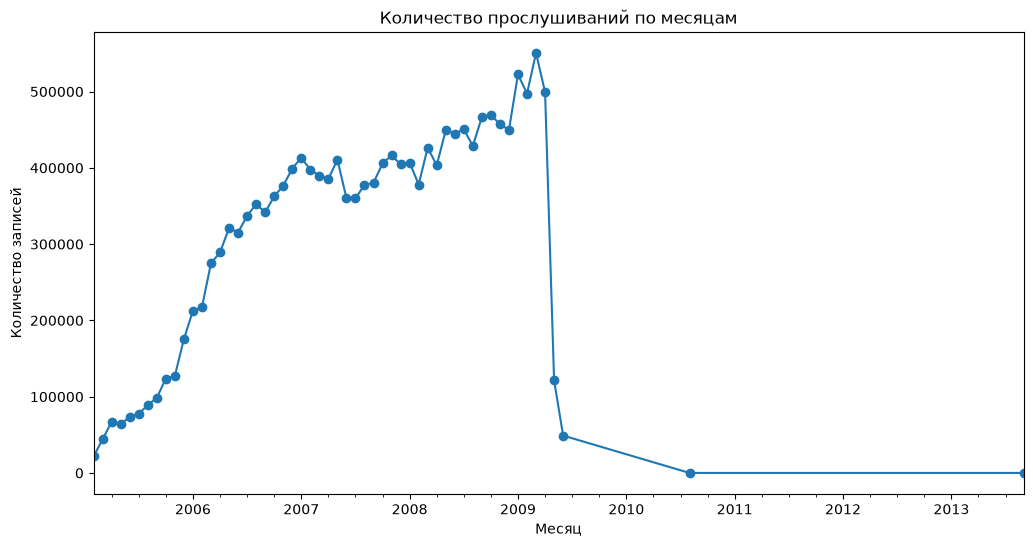

In [23]:
# Добавляем месяц
df['month'] = df['timestamp'].dt.to_period('M')
# Количество записей по месяцам
monthly_counts = df.groupby('month').size()

plt.figure(figsize=(12, 6))
monthly_counts.plot(kind='line', marker='o')
plt.title('Количество прослушиваний по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество записей')

Вкусы со временем меняются, поэтому брать все время излишне.
Решение: берем наблюдения из 2007-2009 гг. так как по ним больше всего данных. 

### 2007-2009

In [13]:
import os
import sys
import pandas as pd 

sys.path.insert(0, os.path.abspath('..'))
from src.data_loader import load_dataset

df_2007 = load_dataset(year=2007)
df_2008 = load_dataset(year=2008)
df_2009 = load_dataset(year=2009)
df_all = pd.concat([df_2007, df_2008, df_2009])

In [14]:
df = df_all.copy()

In [21]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity


# Матрица user × artist (1 — слушал, 0 — нет)
df_unique = df[['user_id', 'artist_name']].drop_duplicates()
# 1. Отбираем топ-5000 исполнителей
top_artists = df_unique['artist_name'].value_counts().head(5000).index
# 2. Фильтруем данные
df_filtered = df_unique[df_unique['artist_name'].isin(top_artists)]
# 3. Строим матрицу
user_artist_matrix = pd.crosstab(df_filtered['user_id'], df_filtered['artist_name'])

# Преобразуем в numpy (явно)
X = np.array(user_artist_matrix, dtype=np.float32)

# Считаем сходство
similarity_matrix = cosine_similarity(X)

# ==================== ТОП ПАР ====================
# Убираем диагональ
np.fill_diagonal(similarity_matrix, 0)

# Находим топ-10 пар
pairs = []
for i in range(len(similarity_matrix)):
    for j in range(i+1, len(similarity_matrix)):
        pairs.append({
            'user1': user_artist_matrix.index[i],
            'user2': user_artist_matrix.index[j],
            'similarity': similarity_matrix[i][j]
        })

pairs_df = pd.DataFrame(pairs).sort_values('similarity', ascending=False).head(10)

# Страна, пол, возраст пользователя (берем первое значение из df)
user_info = df.groupby('user_id')[['country', 'gender', 'age']].first()

# Количество уникальных исполнителей у пользователя
user_unique_artists = user_artist_matrix.sum(axis=1)

# Добавляем колонки
for u, s in [('user1', '1'), ('user2', '2')]:
    pairs_df[f'country{s}'] = pairs_df[u].map(user_info['country'])
    pairs_df[f'gender{s}'] = pairs_df[u].map(user_info['gender'])
    pairs_df[f'age{s}'] = pairs_df[u].map(user_info['age'])
    pairs_df[f'artists{s}'] = pairs_df[u].map(user_unique_artists)

# Переставляем колонки
pairs_df = pairs_df[['user1',  'user2', 'country1', 'country2','artists1', 'artists2', 'age1','age2','gender1','gender2','similarity']]

print(pairs_df.to_string(index=False))

      user1       user2       country1       country2  artists1  artists2  age1  age2 gender1 gender2  similarity
user_000104 user_000301         Norway    Netherlands         1         1   NaN  20.0    None    male    1.000000
user_000431 user_000927         Poland         Poland       597       307   NaN   NaN    male    male    0.705425
user_000650 user_000651  United States  United States       315       508   NaN   NaN    male    male    0.687457
user_000097 user_000791 United Kingdom United Kingdom      1456      1631   NaN   NaN    male    male    0.668390
user_000691 user_000910  United States  United States      1879      1135   NaN   NaN    male    male    0.617654
user_000097 user_000709 United Kingdom         Canada      1456      1047   NaN   NaN    male    male    0.609065
user_000691 user_000774  United States  United States      1879      1799   NaN   NaN    male    male    0.602644
user_000681 user_000691  United States  United States      1525      1879   NaN   NaN   

In [23]:
all_pairs_df = pd.DataFrame(pairs).sort_values('similarity', ascending=False)

# Персентили для всех пар
all_similarities = np.array(all_pairs_df['similarity'].values, dtype=np.float64)

print("📊 ПЕРСЕНТИЛИ ДЛЯ ВСЕХ ПАР:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    value = np.percentile(all_similarities, p)
    print(f"  {p}%: {value:.4f}")

📊 ПЕРСЕНТИЛИ ДЛЯ ВСЕХ ПАР:
  10%: 0.0108
  25%: 0.0527
  50%: 0.1144
  75%: 0.1865
  90%: 0.2556
  95%: 0.2988
  99%: 0.3796


In [ ]:
df_uniqeu = df[['user_id','gender']].drop_duplicates()
df_uniqeu['gender'].value_counts()

gender
male      499
female    380
Name: count, dtype: int64

Есть баланс классов. Возраст может быть параметром для модели.

Что насчет схожести исполнителей?

In [25]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# ==================== МАТРИЦА "ИСПОЛНИТЕЛЬ × ПОЛЬЗОВАТЕЛЬ" ====================

# Убираем дубликаты
df_unique = df[['user_id', 'artist_name']].drop_duplicates()

# Топ-5000 исполнителей
top_artists = df_unique['artist_name'].value_counts().head(5000).index
df_filtered = df_unique[df_unique['artist_name'].isin(top_artists)]

# Строим матрицу (исполнитель × пользователь)
artist_user_matrix = pd.crosstab(df_filtered['artist_name'], df_filtered['user_id'])

print(f"Матрица: {artist_user_matrix.shape}")

# ==================== КОСИНУСНАЯ БЛИЗОСТЬ ====================

X = np.array(artist_user_matrix, dtype=np.float32)
artist_similarity = cosine_similarity(X)
np.fill_diagonal(artist_similarity, 0)

print("✅ Сходство исполнителей посчитано")

Матрица: (5000, 976)
✅ Сходство исполнителей посчитано


In [26]:
# Собираем пары похожих исполнителей
pairs = []
artists = artist_user_matrix.index.tolist()

for i in range(len(artist_similarity)):
    for j in range(i + 1, len(artist_similarity)):
        if artist_similarity[i][j] > 0:
            pairs.append({
                'artist1': artists[i],
                'artist2': artists[j],
                'similarity': artist_similarity[i][j]
            })

pairs_df = pd.DataFrame(pairs).sort_values('similarity', ascending=False).head(10)

print("\nТОП-10 САМЫХ ПОХОЖИХ ИСПОЛНИТЕЛЕЙ:")
print(pairs_df.to_string(index=False))


ТОП-10 САМЫХ ПОХОЖИХ ИСПОЛНИТЕЛЕЙ:
               artist1                          artist2  similarity
      Evan Rachel Wood                      T.V. Carpio    0.813954
        Dread Zeppelin                     Led Zeppelin    0.803837
Bono & Secret Machines Carol Woods & Timothy T. Mitchum    0.801875
          Led Zeppelin                     Lez Zeppelin    0.799886
      Evan Rachel Wood                     Joe Anderson    0.781418
        Dread Zeppelin                     Lez Zeppelin    0.775300
            Dana Fuchs                      T.V. Carpio    0.773309
               Minus 8                     Mo' Horizons    0.772827
                  Beck                        Radiohead    0.771234
          Jim Sturgess                      T.V. Carpio    0.769622


In [28]:
import numpy as np

# Все значения сходства из pairs
similarities = [p['similarity'] for p in pairs]

print("📊 ПЕРСЕНТИЛИ СХОДСТВА ИСПОЛНИТЕЛЕЙ:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  {p}%: {np.percentile(similarities, p):.4f}")

📊 ПЕРСЕНТИЛИ СХОДСТВА ИСПОЛНИТЕЛЕЙ:
  10%: 0.0397
  25%: 0.0724
  50%: 0.1216
  75%: 0.1838
  90%: 0.2511
  95%: 0.2992
  99%: 0.4080


Хоть в топе и высокий уровень схожести, общий уровень схожести исполнителей небольшой.

In [ ]:
# Фильтруем по датам
start = '2007-01-01'
train_end = '2007-12-24'
test_start = '2007-12-25'
test_end = '2007-12-31'

# Отсекаем выбросы (99-й перцентиль)
research = df[(df['timestamp'] >= start) & (df['timestamp'] <= test_end)]
user_activity = research.groupby('user_id').size()
threshold = np.percentile(user_activity, 99)
df_filtered = research[research.groupby('user_id')['user_id'].transform('size') <= threshold]

# Разбиваем на train и test
df_train = df_filtered[(df_filtered['timestamp'] >= start) & (df_filtered['timestamp'] <= train_end)]
df_test = df_filtered[(df_filtered['timestamp'] >= test_start) & (df_filtered['timestamp'] <= test_end)]

# Количество уникальных треков на пользователя в тестовом наборе
test_user_tracks = df_test.groupby('user_id')['track_index'].nunique()

# Медиана
median_tracks = test_user_tracks.median()
print(f"Медиана уникальных треков в тесте: {median_tracks:.0f}")

# Дополнительная статистика
print(f"Среднее: {test_user_tracks.mean():.1f}")
print(f"Максимум: {test_user_tracks.max()}")
print(f"Минимум: {test_user_tracks.min()}")
print(f"25-й перцентиль: {test_user_tracks.quantile(0.25):.0f}")
print(f"75-й перцентиль: {test_user_tracks.quantile(0.75):.0f}")

Медиана уникальных треков в тесте: 66
Среднее: 102.0
Максимум: 698
Минимум: 1
25-й перцентиль: 24
75-й перцентиль: 141
